# CPWL spectral operator through the matrix sign map
Convergence of a decomposition-free CPWL operator, built from the Newton–Schulz msgn surrogate, to the exact operator read off a signed SVD. Plot 1: relative Frobenius error against the iteration count k, one curve per degree D. Plot 2: for one D, the operator's output spectrum at a few values of k against the input singular values and the exact target profile. The error run stops once the error reaches `eps` (default: 10 machine epsilons) and holds it until `k_max`. Edit the config and rerun.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_operator import CPWLOperatorConfig, run_cpwl_convergence, run_cpwl_spectrum
%matplotlib inline

## Plot 1: error against iterations, several degrees D

In [24]:
cfg = CPWLOperatorConfig(
    m=64, n=64, rank=64, cond=1e3, sigma_max=1.0,
    profile="clip", alpha=0.2, beta=0.5,
    degrees=[1, 2, 3, 4],
    k_max=50,     # steps for plot 1 (each internal sign call runs exactly k steps)
    eps=1e-10,     # plot 1 stops once the operator error reaches this; None = 10 machine eps
    D_show=1, k_show=[1, 5, 10],   # plot 2: fixed step counts, no stopping rule
    dtype=torch.float64, device="cuda", seed=0,
)
res = run_cpwl_convergence(cfg)
res2 = run_cpwl_spectrum(cfg)

In [ ]:
plots.plot_error_curves(
    res["error"], ylabel="relative Frobenius error",
    eps=cfg.eps,           # None = no markers or line
    show_first_hit=True,   # mark the first step with error <= eps
    show_eps_line=True,    # horizontal line at eps
    k_plot=None,           # last step shown (None = all)
);

## Plot 2: spectrum convergence, one degree D

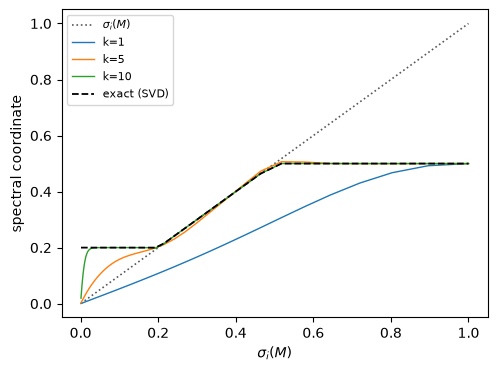

In [26]:
plots.plot_spectrum(res2["sigma"], res2["target"], res2["coords"], xaxis = "sigma");